In [15]:
import numpy as np
import pandas as pd
import sys
import phate
sys.path.append("../utils")
sys.path.append("../training")
import matplotlib.pyplot as plt
import matplotlib
import os
from sklearn.neighbors import NearestNeighbors

from umap import UMAP
from sklearn.decomposition import PCA
from sklearn.preprocessing import StandardScaler

from geometric_features import get_path_sig, get_path_sigs
import iisignature
from stage_dataset import StageDataset
from tqdm.auto import tqdm
from umap import UMAP


from scipy.spatial.distance import cdist
from sklearn.feature_selection import SelectKBest
from sklearn.feature_selection import f_classif
from sklearn.feature_selection import mutual_info_classif
from sklearn.feature_selection import chi2
from sklearn.ensemble import RandomForestClassifier
from stats_utils import RunningStats, prfcm, disp_cm
import torch
from sklearn.metrics import normalized_mutual_info_score
from sklearn.metrics import rand_score
from tslearn.metrics import dtw

tqdm.pandas()

ImportError: cannot import name 'RunningStats' from 'stats_utils' (/home/jenslundsgaard/ivf/analysis/../utils/stats_utils.py)

In [2]:
# hyperparameters
PHASES = ["tPB2", "tPNa", "tPNf", "t2", "t3", "t4", "t5", "t6", "t7", "t8", "t9+", "tM", "tSB", "tB", "tEB"]
model_name = "convlstm_final-2026-07-13"
TIME_OFFSET = 5
PCA_DIM = 8
path_sig_depth = 2
GRADE_COLORS = {"A":(0,1,0), "B":(1,1,0), "C":(1,0,0), "NA":(0.5,0.5,0.5)}
grade = "TE" # "TE"

In [3]:
# load latents and metadata
metadata_df = pd.read_csv(os.path.join("latents",f"{model_name}.csv"))
latents = np.load(os.path.join("latents",f"{model_name}.npy"))
metadata_df = metadata_df.fillna('NA')
id_set = set(metadata_df["embryo_id"].unique())
for p in ["tPNf", "tM"]:
    ids = metadata_df[metadata_df["phase"]==p]["embryo_id"].unique()
    id_set &= set(ids)
    print(p, ": ",len(ids))
id_list = list(id_set)
stripped_phases = ["tPNf","t2", "t3", "t4", "t5", "t6", "t7", "t8", "t9+", "tM", ]
mask = metadata_df["phase"].isin(stripped_phases) & metadata_df["embryo_id"].isin(id_list)
#"tPB2", "tPNa",  "tSB", "tB"
# only graded 
latents = latents[mask]
metadata_df = metadata_df[mask]
latents_df = pd.DataFrame(latents, columns=[f"z_{i}" for i in range(latents.shape[1])], index=metadata_df.index)
pca_cols = [f"pca_{i}" for i in range(PCA_DIM)]
pca = PCA(n_components=PCA_DIM)
pca_latents = pca.fit_transform(StandardScaler().fit_transform(latents))
print(pca.explained_variance_ratio_)
pca_latents_df = pd.DataFrame(pca_latents, columns=pca_cols, index=metadata_df.index)
df = pd.concat([metadata_df, latents_df, pca_latents_df], axis=1)



tPNf :  693
tM :  555
[0.22587463 0.10143861 0.05593139 0.04729208 0.04556353 0.04037918
 0.03184653 0.0295997 ]


In [4]:
ps_cols = [f"path_sig_{i}" for i in range(len(iisignature.basis(iisignature.prepare(PCA_DIM+1, path_sig_depth))))]

def path_sig_agg(group):
    pca_traj = group[pca_cols].to_numpy()
    path_sig = get_path_sig(pca_traj, path_sig_depth, time_offsets=TIME_OFFSET)
    out_df = pd.DataFrame(path_sig[None, :], columns = ps_cols)
    
    out_df["grade"] = [group.iloc[0][grade]]
    return out_df
path_sig_df = df.groupby("embryo_id").progress_apply(path_sig_agg).reset_index()
print(len(path_sig_df))


  0%|          | 0/547 [00:00<?, ?it/s]

547


/home/jenslundsgaard/ivf/.venv/lib/python3.12/site-packages/tqdm/std.py:917: FutureWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  return getattr(df, df_function)(wrapper, **kwargs)


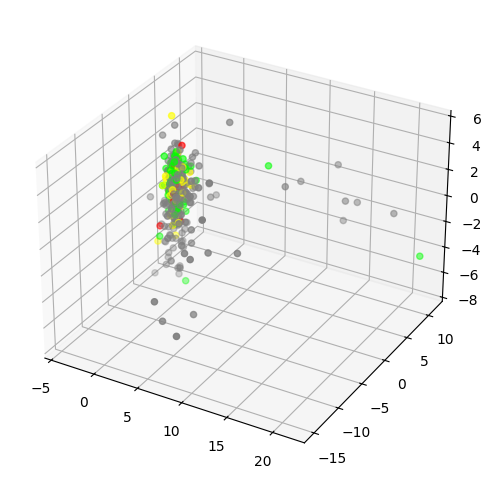

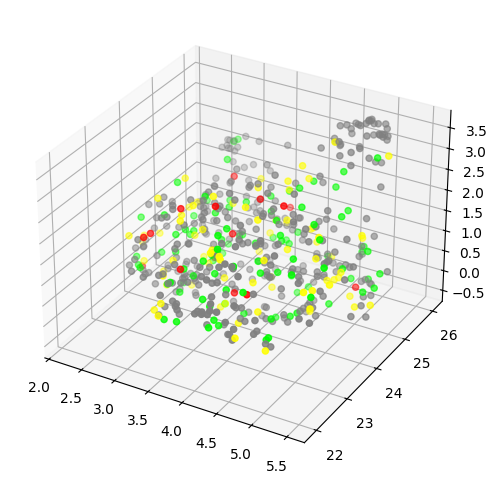

In [5]:
%matplotlib inline
GRADES = ["A","B", "C","NA"]
path_sig_df["grade_indices"]  = [GRADES.index(p) for p in path_sig_df['grade'].to_list()]
PS_PCA_SIZE = 3

normed_path_sigs = StandardScaler().fit_transform(path_sig_df[ps_cols].to_numpy())
visual_ps = PCA(n_components=PS_PCA_SIZE).fit_transform(normed_path_sigs)
visual_ps_grade_indices = path_sig_df["grade_indices"].to_list()
visual_ps_grades = [GRADES[g] for g in visual_ps_grade_indices]
visual_ps_colors = [GRADE_COLORS[g] for g in visual_ps_grades]
fig, ax = plt.subplots(figsize=(8,6), subplot_kw={"projection":"3d"})
ax.scatter(visual_ps[:,0], visual_ps[:,1], visual_ps[:,2], c=visual_ps_colors)#, visual_ps[:,2]
plt.show()
plt.close(fig)
plt.close()


normed_path_sigs = StandardScaler().fit_transform(path_sig_df[ps_cols].to_numpy())
visual_ps = UMAP(n_components=PS_PCA_SIZE).fit_transform(normed_path_sigs)
visual_ps_grade_indices = path_sig_df["grade_indices"].to_list()
visual_ps_grades = [GRADES[g] for g in visual_ps_grade_indices]
visual_ps_colors = [GRADE_COLORS[g] for g in visual_ps_grades]
fig, ax = plt.subplots(figsize=(8,6), subplot_kw={"projection":"3d"})
ax.scatter(visual_ps[:,0], visual_ps[:,1], visual_ps[:,2], c=visual_ps_colors)#, visual_ps[:,2]
plt.show()
plt.close(fig)
plt.close()


In [6]:
def phase_ri(phase_df1, phase_df2, normalize=True):
    phase_df1 = phase_df1[phase_df1["stage"].isin(stripped_phases)] 
    phase_df2 = phase_df2[phase_df2["stage"].isin(stripped_phases)] 
    # normalize so that both have tPB2 start at 0 
    if(normalize):
        phase_df1.loc[:,["stage_begin", "stage_end"]] -= phase_df1.iloc[0]["stage_begin"]# first row is tPB2
        phase_df2.loc[:,["stage_begin", "stage_end"]] -= phase_df2.iloc[0]["stage_begin"]# first row is tPB2

    # turn into columns of index values
    new_column1 = []
    
    for index, row in phase_df1.iterrows():
        new_column1 += [StageDataset.PHASES.index(row["stage"])] * (row["stage_end"] - row["stage_begin"]+1)
    new_column2 = []
    
    for index, row in phase_df2.iterrows():
        new_column2 += [StageDataset.PHASES.index(row["stage"])] * (row["stage_end"] - row["stage_begin"]+1)
    
    new_column1 += [StageDataset.PHASES.index("post_phase")] * (max(len(new_column1),len(new_column2)) - len(new_column1))
    new_column2 += [StageDataset.PHASES.index("post_phase")] * (max(len(new_column1),len(new_column2)) - len(new_column2))
    assert len(new_column1) == len(new_column2), "new col lens are not the same"
    new_column1 = np.array(new_column1)
    new_column2 = np.array(new_column2)
    r_score = rand_score(new_column1, new_column2)
    total = np.concatenate([new_column1, new_column2], axis=0)
    std_dev = total.std()
    mean = total.mean()
    new_column1 = (new_column1 - mean) / (std_dev + 1e-6)
    new_column2 = (new_column2 - mean) / (std_dev + 1e-6)
    alignment = dtw(new_column1, new_column2)
    return r_score, alignment
   
    

[[  0 467 458 ... 415  42 164]
 [  1 329 241 ...  69 462 405]
 [  2 406 367 ... 414 230  80]
 ...
 [544 422 326 ... 455 379 356]
 [545 312 206 ... 271 364 266]
 [546 283  53 ... 291  15  66]]
DM235-3  NA  - 1808.5296752475078 - GD391-9  NA
  stage  stage_begin  stage_end
1  tPNf           71         76
2    t2           77        108
3    t3          109        109
4    t4          110        142
5    t6          143        147
6    t8          148        184
7   t9+          185        250
8    tM          251        277
  stage  stage_begin  stage_end
1  tPNf          101        112
2    t2          113        161
3    t3          162        163
4    t4          164        223
5    t5          224        225
6    t7          226        231
7    t8          232        301
8   t9+          302        361
9    tM          362        400
rand score: 0.8529319955406912
dtw score: 11.640181373218809
-------------------------------------------------- 

DE069-7  A  - 1814.532333980152 - VA19

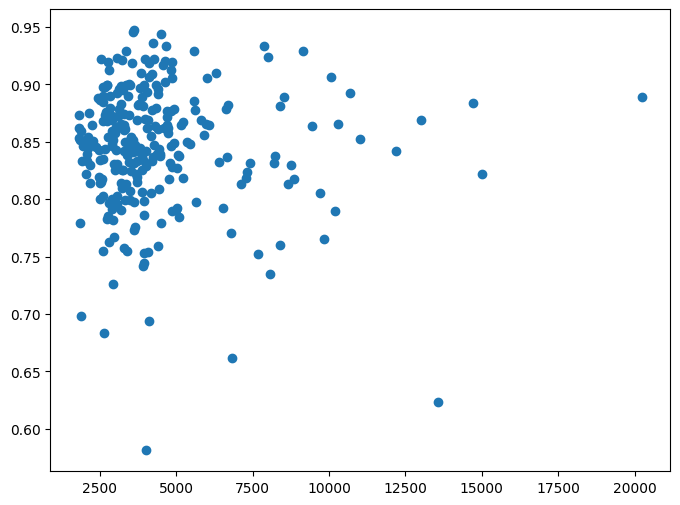

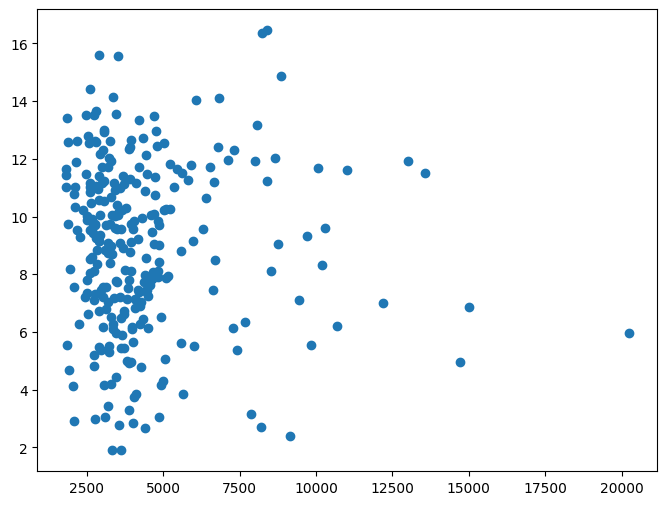

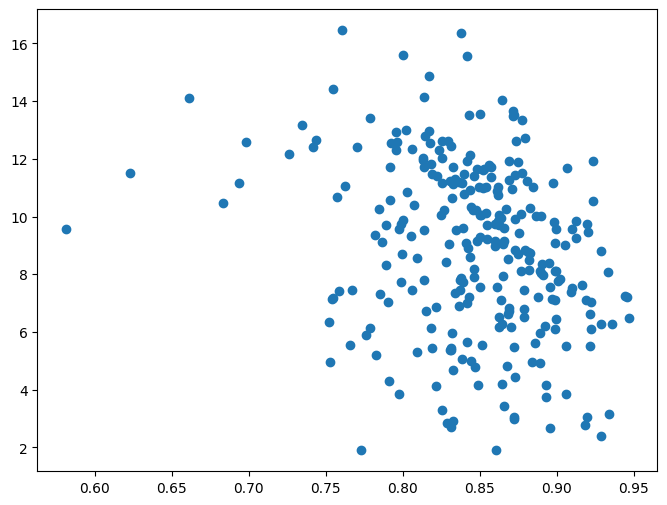

In [9]:
nbrs = NearestNeighbors(n_neighbors=50, algorithm='ball_tree').fit(path_sig_df[ps_cols].to_numpy())
distances, indices = nbrs.kneighbors(path_sig_df[ps_cols].to_numpy())

print(indices)

nn_df = pd.DataFrame({"dist":distances[:,1],"i1":indices[:,0],"i2":indices[:,1]})
nn_df = nn_df.sort_values(by="dist")
distances = nn_df["dist"].to_list()
idxs1 = nn_df["i1"].to_list()
idxs2 = nn_df["i2"].to_list()
limit = 1000

dists = []
r_scores = {i:RunningStats()}
dtw_scores = []

for (i1, i2, d) in list(zip(idxs1,idxs2,distances))[:limit:2]: # symmetric, remove every other
    row1 = path_sig_df.iloc[i1]
    row2 = path_sig_df.iloc[i2]
    print(row1["embryo_id"], f" {row1['grade']}", f" - {d} -", row2["embryo_id"], f" {row2['grade']}")
    
    phase_df1 = pd.read_csv(os.path.join("embryo_dataset_annotations",f"{row1["embryo_id"]}_phases.csv"), header=0) 
    phase_df1.columns = ["stage", "stage_begin","stage_end"]
    print(phase_df1[phase_df1["stage"].isin(stripped_phases)])
    
    phase_df2 = pd.read_csv(os.path.join("embryo_dataset_annotations",f"{row2["embryo_id"]}_phases.csv"), header=0)
    phase_df2.columns = ["stage", "stage_begin","stage_end"]
    print(phase_df2[phase_df2["stage"].isin(stripped_phases)])
    
    score, alignment = phase_ri(phase_df1, phase_df2)
    
    print(f"rand score: {score}")
    print(f"dtw score: {alignment}")
    
    r_scores.append(score)
    dists.append(d)
    dtw_scores.append(alignment)
    print("-"*50,"\n")
    
fig, ax = plt.subplots(figsize=(8,6))
ax.scatter(dists, r_scores)#, visual_ps[:,2]
plt.show()
plt.close(fig)
plt.close()

fig, ax = plt.subplots(figsize=(8,6))
ax.scatter(dists, dtw_scores)#, visual_ps[:,2]
plt.show()
plt.close(fig)
plt.close()

fig, ax = plt.subplots(figsize=(8,6))
ax.scatter(r_scores, dtw_scores)#, visual_ps[:,2]
plt.show()
plt.close(fig)
plt.close()




In [8]:
embryos = metadata_df["embryo_id"].unique()
for _ in range(20):
    np.random.shuffle(embryos)
    embryo1, embryo2 = embryos[:2]
    phase_df1 = pd.read_csv(os.path.join("embryo_dataset_annotations", f"{embryo1}_phases.csv"), header=0) 
    phase_df1.columns = ["stage", "stage_begin","stage_end"]
    print(phase_df1[phase_df1["stage"].isin(stripped_phases)])
    
    phase_df2 = pd.read_csv(os.path.join("embryo_dataset_annotations", f"{embryo2}_phases.csv"), header=0)
    phase_df2.columns = ["stage", "stage_begin","stage_end"]
    print(phase_df2[phase_df2["stage"].isin(stripped_phases)])
    score, alignment = phase_ri(phase_df1, phase_df2)
    print(f"rand score: {score}")
    print(f"dtw score: {alignment}")


  stage  stage_begin  stage_end
1  tPNf          126        141
2    t2          142        205
3    t4          206        273
4    t8          274        380
5   t9+          381        482
6    tM          483        542
  stage  stage_begin  stage_end
1  tPNf           88         97
2    t2           98        145
3    t3          146        149
4    t4          150        195
5    t6          196        199
6    t7          200        209
7    t8          210        278
8   t9+          279        350
9    tM          351        389
rand score: 0.8395706511713706
dtw score: 13.433329053416717
  stage  stage_begin  stage_end
1  tPNf           68         76
2    t2           77        115
3    t4          116        162
4    t7          163        163
5    t8          164        240
6   t9+          241        280
7    tM          281        314
  stage  stage_begin  stage_end
0  tPNf           98        110
1    t2          111        112
2    t3          113        158
3    t4    